In [72]:
import librosa
import os 
import numpy as np 
import matplotlib.pyplot as plt 
import librosa.display
import pandas as pd
import random

In [73]:
playlist_titles = os.listdir('sample_playlist')

In [74]:
playlist_dict = {}

Loading the playlist up 

In [75]:
#for now hardcode the sr 
sr=22050

for i in playlist_titles:
    y,sr=librosa.load(f'sample_playlist/{i}')
    playlist_dict[i] = y 

Taking 30 random 5 second samples

In [76]:
#aa = audio array also use y elsewhere
aa = playlist_dict['51 Days - Paper Moon.mp3'] #dictionary of the ys
song_length = librosa.get_duration(y=aa,sr=sr)
#rtl = random timestamp list
samples = np.random.randint(0,int(song_length-3),30)
samples_range = np.column_stack((samples,samples+3))

segments = []
for j in samples_range:
    start_time = j[0] * sr
    end_time = j[1] * sr
    segment_j = aa[start_time:end_time] 
    segments.append(segment_j)

Now on each of these samples we want to extract our desired features

Features 
1. log spaced mel spectrogram
2. chroma stft
3. spectral contrast

In [77]:
aa_melspec = librosa.feature.melspectrogram(y=aa) #default window 2048, hop 512
aa_logmelspec = librosa.power_to_db(aa_melspec)
aa_chroma = librosa.feature.chroma_stft(y=aa)
aa_spectralcon = librosa.feature.spectral_contrast(y=aa)

In [78]:
import librosa
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

SR = 22050
playlist_dir = 'sample_playlist'
playlist_titles = os.listdir(playlist_dir)
playlist_dict = {}

for title in playlist_titles:
    y, _ = librosa.load(f'{playlist_dir}/{title}', sr=SR)
    playlist_dict[title] = y


In [79]:
def extract_segment_features(y, sr=SR, n_segments=30, seg_duration=3):
    song_length = librosa.get_duration(y=y, sr=sr)

    starts = np.random.randint(0, int(song_length - seg_duration), n_segments)

    seg_features = []

    for start in starts:
        segment = y[start*sr : (start + seg_duration)*sr]

        mel = librosa.feature.melspectrogram(y=segment)
        log_mel = librosa.power_to_db(mel)
        chroma = librosa.feature.chroma_stft(y=segment)
        contrast = librosa.feature.spectral_contrast(y=segment)
        
        seg_vec = np.concatenate([
            log_mel.mean(axis=1), log_mel.std(axis=1),    
            chroma.mean(axis=1), chroma.std(axis=1),
            contrast.mean(axis=1), contrast.std(axis=1)   
        ])

        seg_features.append(seg_vec)

    seg_features = np.array(seg_features)
    song_vector = np.concatenate([
        seg_features.mean(axis=0),
        seg_features.std(axis=0)
    ])

    return song_vector

In [80]:
print("Extracting features...")
song_names = []
feature_vectors = []

for title, y in playlist_dict.items():
    print(f"  Processing: {title}")
    vec = extract_segment_features(y)
    song_names.append(title)
    feature_vectors.append(vec)

X = np.array(feature_vectors)  # (N, 588)

Extracting features...
  Processing: &friends, JOSEPH (CH), Brent Faiyaz - Jackie B.mp3
  Processing: 51 Days - Paper Moon.mp3
  Processing: Bakermat - Baianá.mp3
  Processing: D Stone - Total Unison.mp3
  Processing: J $ENSEI - NO PASA NADA.mp3
  Processing: L.I.T - Beat Won't Stop.mp3
  Processing: PAWSA - A LITTLE BIT FUNKIER.mp3
  Processing: Quliano - NYC.mp3
  Processing: Sacha Robotti - Think About U.mp3
  Processing: Wade - Pan Jabi.mp3


In [81]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)  # values between 0 and 1

sim_matrix = cosine_similarity(X_scaled)

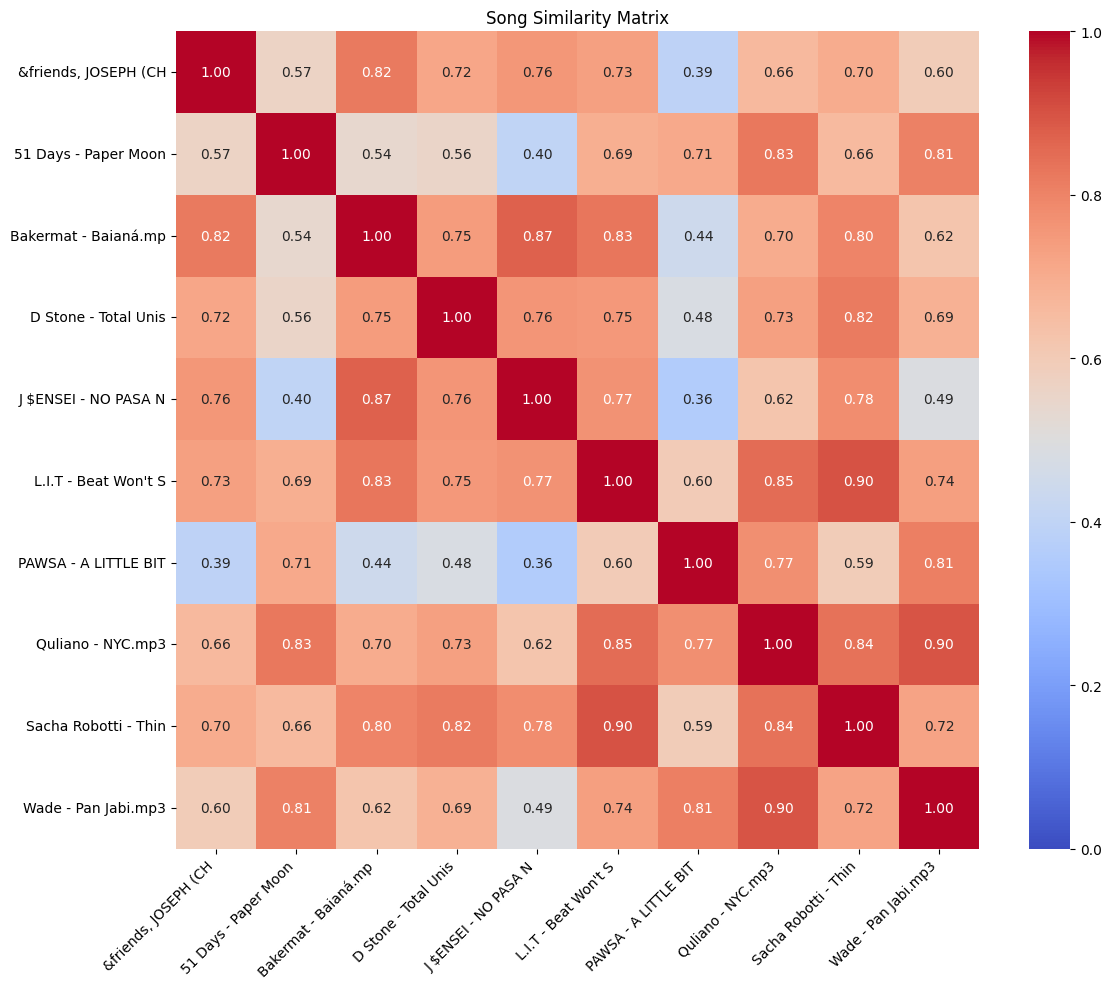

In [82]:
sim_df = pd.DataFrame(sim_matrix,index=song_names,columns=song_names)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(
    sim_df,
    annot=True,        # show numbers in cells
    fmt=".2f",         # 2 decimal places
    cmap="coolwarm",   # blue=dissimilar, red=similar
    vmin=0, vmax=1,
    xticklabels=[name[:20] for name in song_names],  # truncate long names
    yticklabels=[name[:20] for name in song_names]
)
plt.title("Song Similarity Matrix")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()